In [2]:
import math
import csv

from scipy.stats import norm

In [3]:
def binomial_confidence_interval(accuracy_percent, confidence=95, n=1000):
    z = norm.ppf(1 - (1 - confidence / 100) / 2)
    p = accuracy_percent / 100
    se = (p * (1 - p) / n) ** 0.5
    margin = z * se
    lower = max(0, p - margin)
    upper = min(1, p + margin)
    return accuracy_percent, lower * 100, upper * 100  # All in percent

In [16]:
# table_data = [
#     [98.5, 98.0, 98.2, 97.9],
#     [98.0, 98.1, 98.4, 98.0],
#     [98.9, 98.3, 98.2, 98.1],
#     [99.8, 98.4, 98.7, 98.3]
# ]

# table_data = [
#     [98.6, 98.0, 98.0, 97.9],
#     [98.7, 98.1, 98.0, 97.9],
#     [98.8, 98.2, 98.5, 98.0],
#     [99.0, 98.5, 98.7, 98.1]
# ]

# table_data = [
#     [88.8, 83.4, 87.6, 81.2],
#     [96.3, 95.2, 95.7, 94.9],
#     [96.4, 95.2, 96.3, 94.3],
#     [96.7, 96.0, 96.2, 94.6]
# ]

table_data = [
    [86.5, 82.0, 85.9, 81.8],
    [95.1, 94.9, 94.5, 94.4],
    [96.0, 95.1, 95.7, 94.4],
    [97.0, 95.5, 96.2, 95.1]
]


for row in table_data:
    for i in range(len(row)):
        score, score_lower, score_upper = binomial_confidence_interval(row[i], confidence=95, n=5000)
        
        # Since bounds are symmetric, we compute a single margin
        margin = (score_upper - score)  # same as (left - left_lower)
        
        row[i] = f"{score:.1f}\\%\\textsuperscript{{$\\pm${margin:.2f}}}"
        

# Write to CSV
with open("confidence_intervals.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(table_data)

In [5]:
# 1000
# table_data = [
#     [11.2, 12.8, 94.8, 92.7, 95.5, 93.0, 49.7, 36.7],
#     [10.3, 11.9, 94.9, 93.4, 95.7, 93.5, 62.1, 49.2],
#     [10.2, 12.0, 95.6, 93.0, 96.3, 94.4, 69.4, 63.0],
#     [11.4, 12.1, 96.2, 94.3, 96.6, 94.8, 76.1, 64.2]
# ]

# 2000
table_data = [
    [51.5, 50.0, 95.3, 94.2, 98.0, 97.0, 58.8, 55.5],
    [50.3, 51.0, 95.9, 95.0, 98.1, 97.0, 65.2, 58.9],
    [51.1, 50.3, 96.1, 95.2, 98.0, 97.2, 68.4, 60.3],
    [52.3, 52.0, 97.2, 96.0, 98.2, 97.3, 76.5, 74.1]
]

# 5000
# table_data = [
#     [10.5, 11.2, 74.0, 72.1, 86.7, 84.1, 21.4, 17.9],
#     [11.8, 12.1, 93.9, 91.6, 93.6, 90.3, 55.7, 51.5],
#     [11.0, 10.9, 94.1, 92.0, 94.1, 90.1, 22.9, 20.8],
#     [10.3, 10.0, 94.1, 92.3, 93.0, 91.0, 58.0, 53.5]
# ]

# # 5000
# table_data = [
#     [35.6, 35.2, 75.0, 70.6, 82.6, 78.8, 39.9, 38.2],
#     [36.2, 36.5, 93.4, 92.2, 94.0, 93.3, 64.4, 60.5],
#     [35.5, 34.9, 92.5, 90.3, 94.1, 92.4, 43.7, 41.5],
#     [36.7, 36.3, 94.6, 92.4, 94.4, 92.5, 78.2, 72.4]
# ]




for row in table_data:
    for i in range(0, len(row), 2):
        left, left_lower, left_upper = binomial_confidence_interval(float(row[i]), confidence=95, n=2000)
        right, right_lower, right_upper = binomial_confidence_interval(float(row[i+1]), confidence=95, n=2000)
            
        # bounds are symmetric, compute a single margin
        left_margin = (left_upper - left)  # same as (left - left_lower)
        right_margin = (right_upper - right)
        
        print_left = ""
        print_right = ""

        if left > right:
            print_left += f"{left:.1f}\\%\\textsuperscript{{$\\pm${left_margin:.2f}}}"
            print_right += f"\\textbf{{{right:.1f}\\%}}"
            if left_lower <= right <= left_upper:
                print_right += f"\\textsuperscript{{$\\pm${right_margin:.2f}}}"  # within CI
            else:
                print_right += f"\\textbf{{\\textsuperscript{{$\\pm${right_margin:.2f}}}}}"  # outside CI
        elif left < right:
            print_left += f"\\textbf{{{left:.1f}\\%}}"
            print_right += f"{right:.1f}\\%\\textsuperscript{{$\\pm${right_margin:.2f}}}"
            if right_lower <= left <= right_upper:
                print_left += f"\\textsuperscript{{$\\pm${left_margin:.2f}}}"  # within CI
            else:
                print_left += f"\\textbf{{\\textsuperscript{{$\\pm${left_margin:.2f}}}}}"  # outside CI
        else:
            print_left += f"{left:.1f}\\%\\textsuperscript{{$\\pm${left_margin:.2f}}}"
            print_right += f"{right:.1f}\\%\\textsuperscript{{$\\pm${right_margin:.2f}}}"

        row[i] = print_left
        row[i+1] = print_right

# Write to CSV
with open("confidence_intervals.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(table_data)

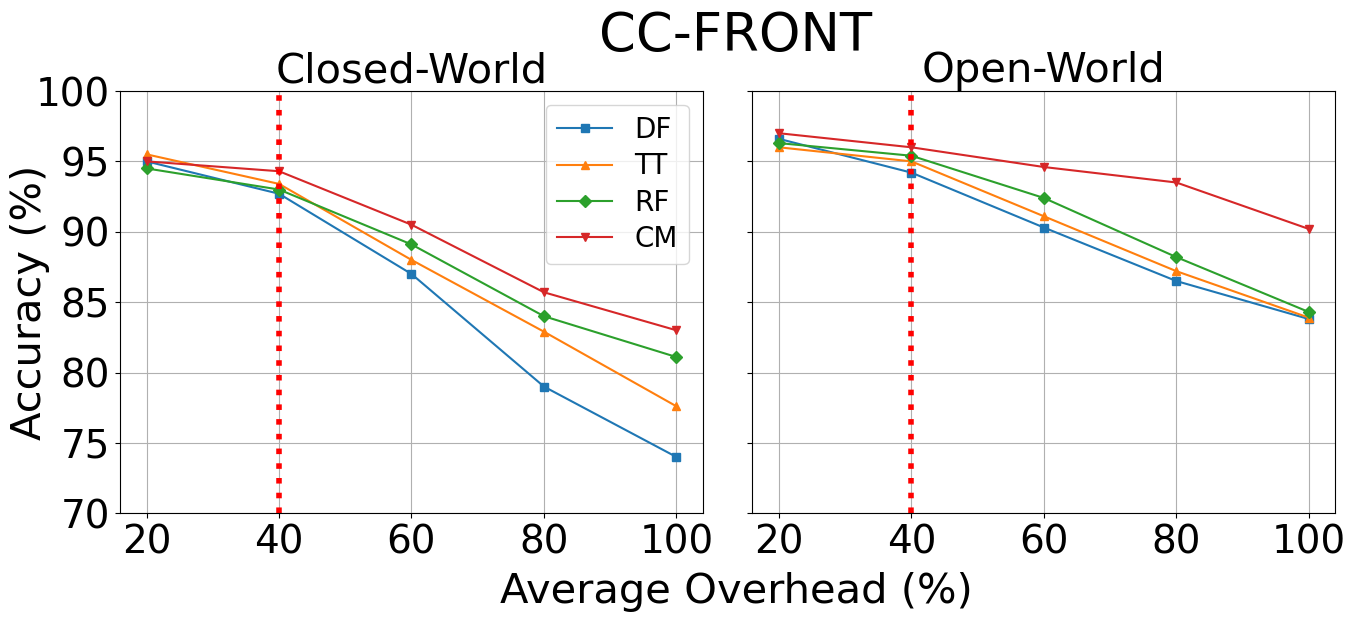

In [ ]:
import matplotlib.pyplot as plt


x_axis = [20,40,60,80,100]

# Data for Chart 1
df1 = [95.0, 92.7, 87.0, 79, 74.0]
tt1 = [95.5, 93.4, 88.0, 82.9, 77.6]
rf1 = [94.5, 93.0, 89.1, 84.0, 81.1]
cm1 = [95.0, 94.3, 90.5, 85.7, 83.0]

# Data for Chart 2
df2 = [96.6, 94.2, 90.3, 86.5, 83.8]
tt2 = [96.0, 95.0, 91.1, 87.2, 83.9]
rf2 = [96.3, 95.4, 92.4, 88.2, 84.3]
cm2 = [97.0, 96.0, 94.6, 93.5, 90.2]

# Classifier styles
classifiers = {
    'DF':   {'data1': df1, 'data2': df2, 'marker': 's'},
    'TT':   {'data1': tt1, 'data2': tt2, 'marker': '^'},
    'RF':   {'data1': rf1, 'data2': rf2, 'marker': 'D'},
    'CM':   {'data1': cm1, 'data2': cm2, 'marker': 'v'},
}

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 20
})

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Chart 1
for label, style in classifiers.items():
    ax1.plot(x_axis, style['data1'], marker=style['marker'], label=label)
ax1.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax1.set_title("Closed-World")
ax1.set_ylabel("Accuracy (%)", labelpad=-10)
ax1.set_xticks([int(x) for x in x_axis])
ax1.set_ylim(70, 100)
ax1.set_yticks(range(70, 101, 5))
ax1.grid(True)
ax1.legend(loc='upper right', labelspacing=0.3)

# Plot Chart 2
for label, style in classifiers.items():
    ax2.plot(x_axis, style['data2'], marker=style['marker'], label=label)
ax2.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax2.set_title("Open-World")
ax2.set_xticks([int(x) for x in x_axis])
ax2.set_ylim(70, 100)
ax2.grid(True)

# Shared x-axis label
fig.text(0.54, 0.95, "CC-FRONT", ha='center', fontsize=38)

fig.text(0.54, 0.03, "Average Overhead (%)", ha='center', fontsize=30)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("front_1tab_overhead.pdf", format='pdf', bbox_inches='tight')

plt.show()

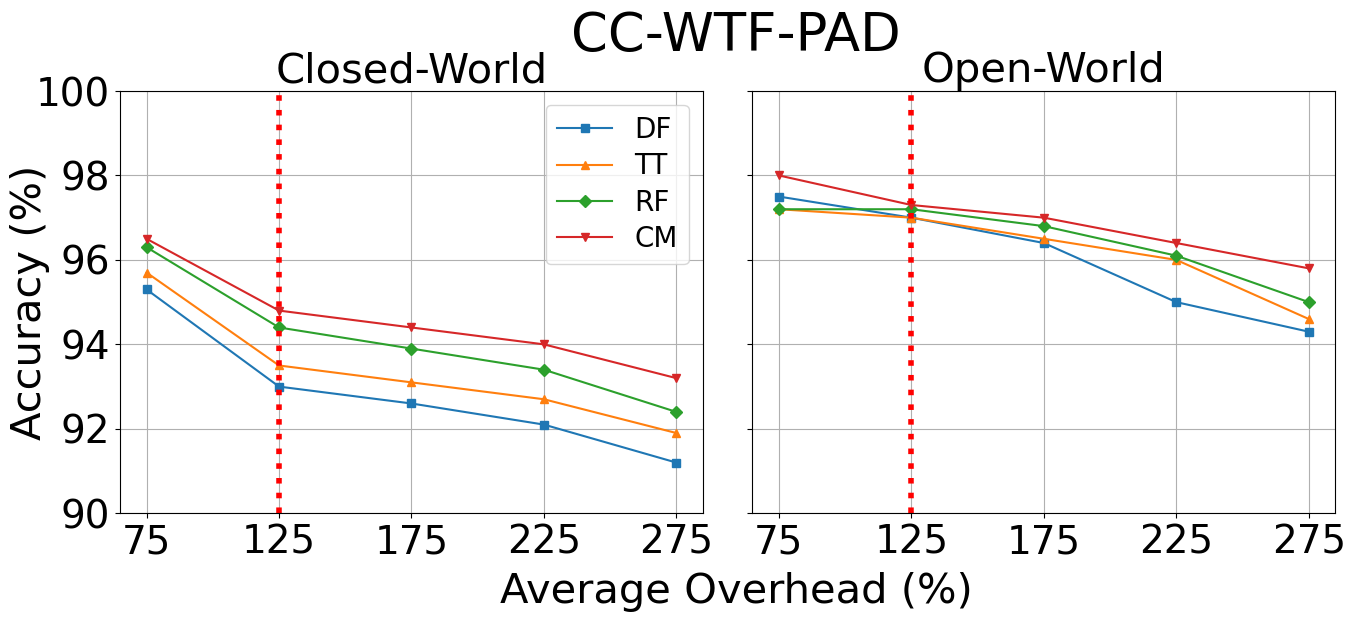

In [88]:
import matplotlib.pyplot as plt

x_axis = [75,125,175,225,275]

# Data for Chart 1
df1 = [95.3, 93.0, 92.6, 92.1, 91.2]
tt1 = [95.7, 93.5, 93.1, 92.7, 91.9]
rf1 = [96.3, 94.4, 93.9, 93.4, 92.4]
cm1 = [96.5, 94.8, 94.4, 94.0, 93.2]

# Data for Chart 2
df2 = [97.5, 97.0, 96.4, 95.0, 94.3]
tt2 = [97.2, 97.0, 96.5, 96.0, 94.6]
rf2 = [97.2, 97.2, 96.8, 96.1, 95.0]
cm2 = [98.0, 97.3, 97.0, 96.4, 95.8]

# Classifier styles
classifiers = {
    'DF':   {'data1': df1, 'data2': df2, 'marker': 's'},
    'TT':   {'data1': tt1, 'data2': tt2, 'marker': '^'},
    'RF':   {'data1': rf1, 'data2': rf2, 'marker': 'D'},
    'CM':   {'data1': cm1, 'data2': cm2, 'marker': 'v'},
}

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 20
})

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Chart 1
for label, style in classifiers.items():
    ax1.plot(x_axis, style['data1'], marker=style['marker'], label=label)
ax1.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax1.set_title("Closed-World")
ax1.set_ylabel("Accuracy (%)", labelpad=-10)
ax1.set_xticks([int(x) for x in x_axis])
ax1.set_ylim(90, 100)
ax1.set_yticks(range(90, 101, 2))
ax1.grid(True)
ax1.legend(loc='upper right', labelspacing=0.3)

# Plot Chart 2
for label, style in classifiers.items():
    ax2.plot(x_axis, style['data2'], marker=style['marker'], label=label)
ax2.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax2.set_title("Open-World")
ax2.set_xticks([int(x) for x in x_axis])
ax2.set_ylim(90, 100)
ax2.grid(True)

# Shared x-axis label
fig.text(0.54, 0.95, "CC-WTF-PAD", ha='center', fontsize=38)

fig.text(0.54, 0.03, "Average Overhead (%)", ha='center', fontsize=30)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("wtfpad_1tab_overhead.pdf", format='pdf', bbox_inches='tight')

plt.show()

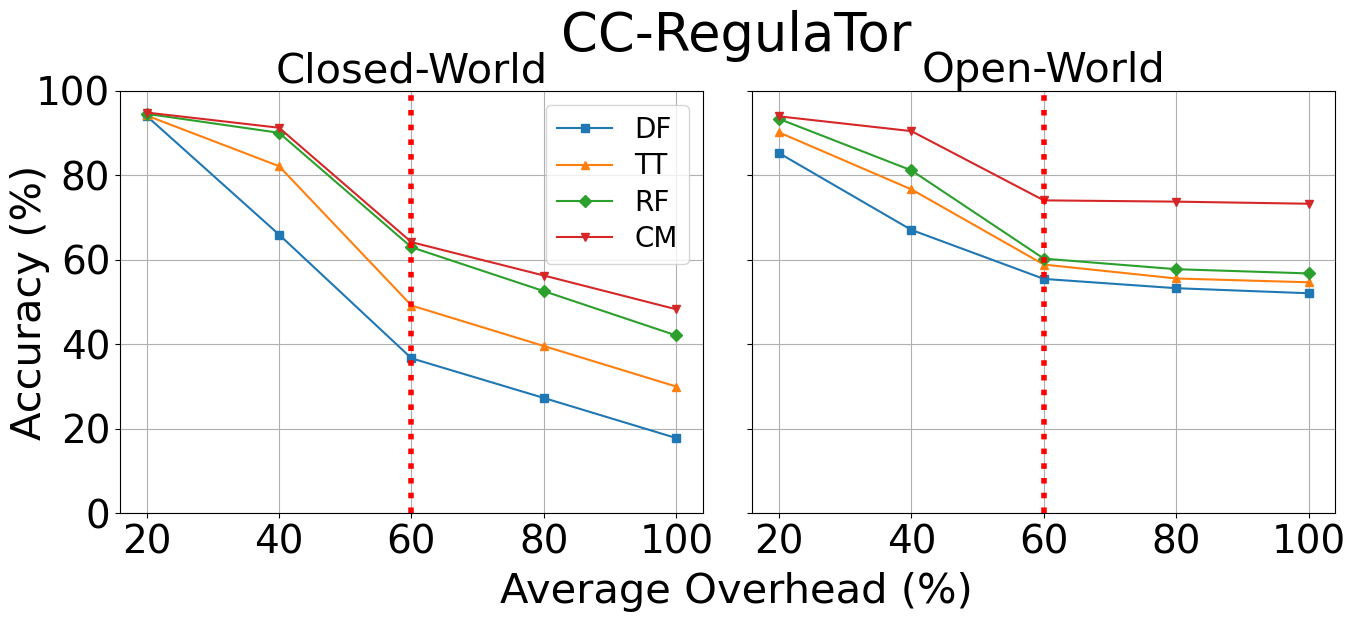

In [97]:
import matplotlib.pyplot as plt

x_axis = [20,40,60,80,100]

# Data for Chart 1
df1 = [94.1, 66.0, 36.7, 27.3, 17.8]
tt1 = [94.2, 82.2, 49.2, 39.6, 30.0]
rf1 = [94.6, 90.1, 63.0, 52.6, 42.1]
cm1 = [94.9, 91.3, 64.2, 56.3, 48.3]

# Data for Chart 2
df2 = [85.3, 67.1, 55.5, 53.3, 52.1]
tt2 = [90.2, 76.7, 58.9, 55.6, 54.7]
rf2 = [93.4, 81.2, 60.3, 57.8, 56.8]
cm2 = [94.0, 90.5, 74.1, 73.8, 73.3]

# Classifier styles
classifiers = {
    'DF':   {'data1': df1, 'data2': df2, 'marker': 's'},
    'TT':   {'data1': tt1, 'data2': tt2, 'marker': '^'},
    'RF':   {'data1': rf1, 'data2': rf2, 'marker': 'D'},
    'CM':   {'data1': cm1, 'data2': cm2, 'marker': 'v'},
}

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 20
})

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Chart 1
for label, style in classifiers.items():
    ax1.plot(x_axis, style['data1'], marker=style['marker'], label=label)
ax1.axvline(x_axis[2], color='red', linestyle=':', linewidth=4)
ax1.set_title("Closed-World")
ax1.set_ylabel("Accuracy (%)", labelpad=-10)
ax1.set_xticks([int(x) for x in x_axis])
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 20))
ax1.grid(True)
ax1.legend(loc='upper right', labelspacing=0.3)

# Plot Chart 2
for label, style in classifiers.items():
    ax2.plot(x_axis, style['data2'], marker=style['marker'], label=label)
ax2.axvline(x_axis[2], color='red', linestyle=':', linewidth=4)
ax2.set_title("Open-World")
ax2.set_xticks([int(x) for x in x_axis])
ax2.set_ylim(0, 100)
ax2.grid(True)

# Shared x-axis label
fig.text(0.54, 0.95, "CC-RegulaTor", ha='center', fontsize=38)

fig.text(0.54, 0.03, "Average Overhead (%)", ha='center', fontsize=30)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("regulator_1tab_overhead.pdf", format='pdf', bbox_inches='tight')

plt.show()

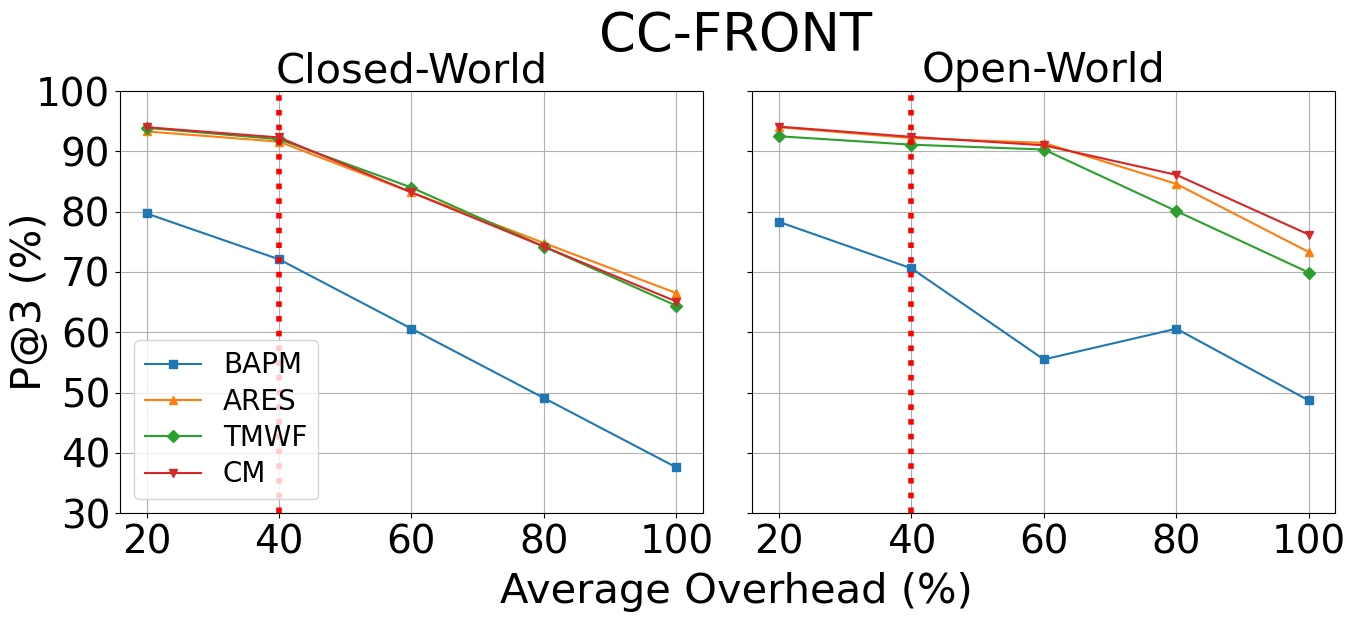

In [116]:
import matplotlib.pyplot as plt

x_axis = [20,40,60,80,100]

# Data for Chart 1
df1 = [79.7, 72.1, 60.6, 49.1, 37.6]
tt1 = [93.3, 91.6, 83.2, 74.8, 66.5]
rf1 = [93.9, 92.0, 84.0, 74.2, 64.4]
cm1 = [94.0, 92.3, 83.2, 74.2, 65.1]

# Data for Chart 2
df2 = [78.3, 70.6, 55.5, 60.6, 48.7]
tt2 = [94.0, 92.2, 91.4, 84.6, 73.3]
rf2 = [92.5, 91.1, 90.3, 80.1, 69.9]
cm2 = [94.1, 92.4, 91.0, 86.1, 76.2]

# Classifier styles
classifiers = {
    'BAPM':   {'data1': df1, 'data2': df2, 'marker': 's'},
    'ARES':   {'data1': tt1, 'data2': tt2, 'marker': '^'},
    'TMWF':   {'data1': rf1, 'data2': rf2, 'marker': 'D'},
    'CM':   {'data1': cm1, 'data2': cm2, 'marker': 'v'},
}

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 20
})

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Chart 1
for label, style in classifiers.items():
    ax1.plot(x_axis, style['data1'], marker=style['marker'], label=label)
ax1.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax1.set_title("Closed-World")
ax1.set_ylabel("P@3 (%)", labelpad=-10)
ax1.set_xticks([int(x) for x in x_axis])
ax1.set_ylim(30, 100)
ax1.set_yticks(range(30, 101, 10))
ax1.grid(True)
ax1.legend(loc='lower left', labelspacing=0.3)

# Plot Chart 2
for label, style in classifiers.items():
    ax2.plot(x_axis, style['data2'], marker=style['marker'], label=label)
ax2.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax2.set_title("Open-World")
ax2.set_xticks([int(x) for x in x_axis])
ax2.set_ylim(30, 100)
ax2.grid(True)

# Shared x-axis label
fig.text(0.54, 0.95, "CC-FRONT", ha='center', fontsize=38)

fig.text(0.54, 0.03, "Average Overhead (%)", ha='center', fontsize=30)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("front_3tab_overhead.pdf", format='pdf', bbox_inches='tight')

plt.show()

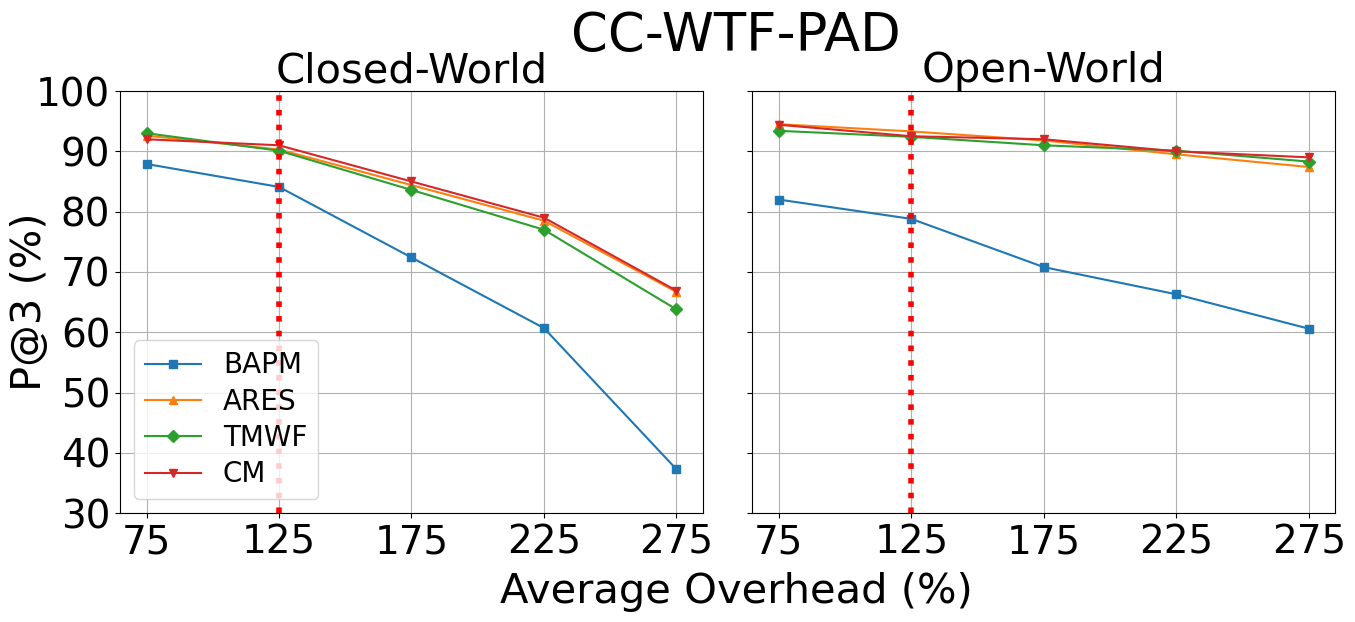

In [117]:
import matplotlib.pyplot as plt

x_axis = [75,125,175,225,275]

# Data for Chart 1
df1 = [87.9, 84.1, 72.4, 60.7, 37.3]
tt1 = [92.6, 90.3, 84.4, 78.5, 66.7]
rf1 = [93.0, 90.1, 83.6, 77.0, 63.8]
cm1 = [92.0, 91.0, 85.0, 79.0, 66.9]

# Data for Chart 2
df2 = [82.0, 78.8, 70.8, 66.3, 60.6]
tt2 = [94.5, 93.3, 91.8, 89.5, 87.4]
rf2 = [93.4, 92.4, 91.0, 90.1, 88.3]
cm2 = [94.4, 92.5, 92.0, 90.0, 89.0]

# Classifier styles
classifiers = {
    'BAPM':   {'data1': df1, 'data2': df2, 'marker': 's'},
    'ARES':   {'data1': tt1, 'data2': tt2, 'marker': '^'},
    'TMWF':   {'data1': rf1, 'data2': rf2, 'marker': 'D'},
    'CM':   {'data1': cm1, 'data2': cm2, 'marker': 'v'},
}

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 20
})

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Chart 1
for label, style in classifiers.items():
    ax1.plot(x_axis, style['data1'], marker=style['marker'], label=label)
ax1.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax1.set_title("Closed-World")
ax1.set_ylabel("P@3 (%)", labelpad=-10)
ax1.set_xticks([int(x) for x in x_axis])
ax1.set_ylim(30, 100)
ax1.set_yticks(range(30, 101, 10))
ax1.grid(True)
ax1.legend(loc='lower left', labelspacing=0.3)

# Plot Chart 2
for label, style in classifiers.items():
    ax2.plot(x_axis, style['data2'], marker=style['marker'], label=label)
ax2.axvline(x_axis[1], color='red', linestyle=':', linewidth=4)
ax2.set_title("Open-World")
ax2.set_xticks([int(x) for x in x_axis])
ax2.set_ylim(30, 100)
ax2.grid(True)

# Shared x-axis label
fig.text(0.54, 0.95, "CC-WTF-PAD", ha='center', fontsize=38)

fig.text(0.54, 0.03, "Average Overhead (%)", ha='center', fontsize=30)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("wtfpad_3tab_overhead.pdf", format='pdf', bbox_inches='tight')

plt.show()

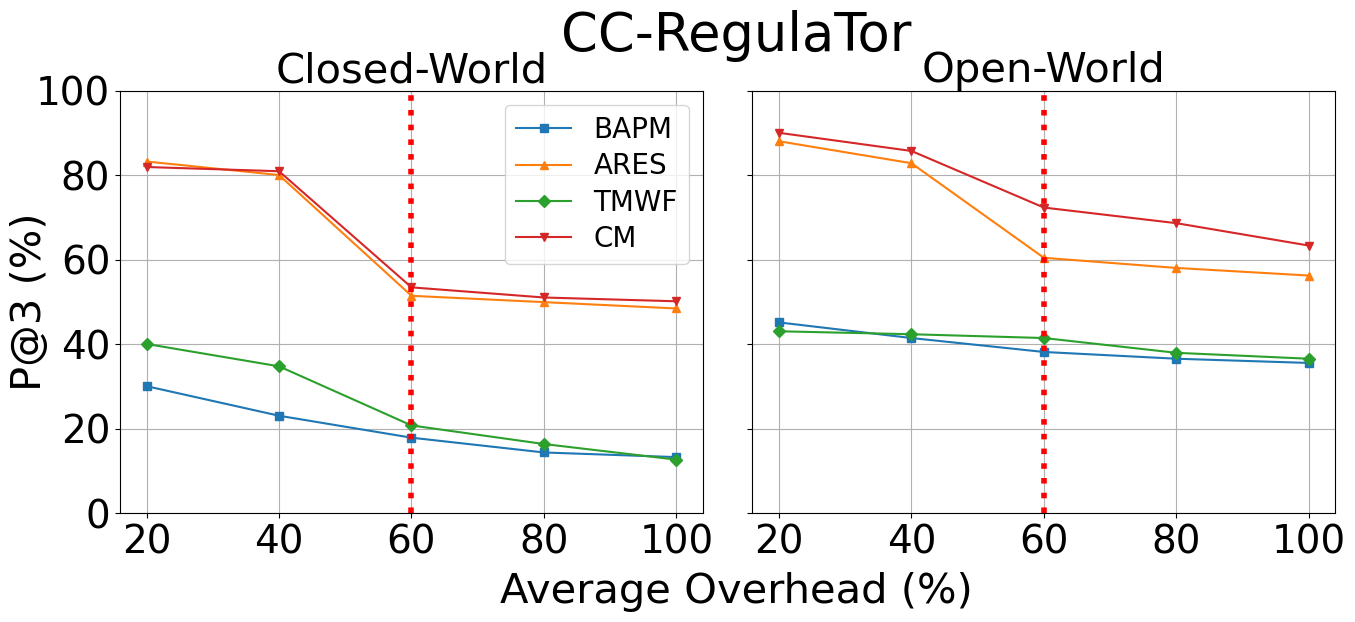

In [120]:
import matplotlib.pyplot as plt

x_axis = [20,40,60,80,100]

# Data for Chart 1
df1 = [30.1, 23.1, 17.9, 14.4, 13.3]
tt1 = [83.3, 80.1, 51.5, 50.0, 48.5]
rf1 = [40.1, 34.8, 20.8, 16.4, 12.7]
cm1 = [82.0, 81.0, 53.5, 51.1, 50.2]

# Data for Chart 2
df2 = [45.2, 41.5, 38.2, 36.6, 35.6]
tt2 = [88.1, 82.9, 60.5, 58.1, 56.3]
rf2 = [43.1, 42.4, 41.5, 38.0, 36.6]
cm2 = [90.1, 85.8, 72.4, 68.7, 63.4]

# Classifier styles
classifiers = {
    'BAPM':   {'data1': df1, 'data2': df2, 'marker': 's'},
    'ARES':   {'data1': tt1, 'data2': tt2, 'marker': '^'},
    'TMWF':   {'data1': rf1, 'data2': rf2, 'marker': 'D'},
    'CM':   {'data1': cm1, 'data2': cm2, 'marker': 'v'},
}

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'legend.fontsize': 20
})

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot Chart 1
for label, style in classifiers.items():
    ax1.plot(x_axis, style['data1'], marker=style['marker'], label=label)
ax1.axvline(x_axis[2], color='red', linestyle=':', linewidth=4)
ax1.set_title("Closed-World")
ax1.set_ylabel("P@3 (%)", labelpad=-10)
ax1.set_xticks([int(x) for x in x_axis])
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 20))
ax1.grid(True)
ax1.legend(loc='upper right', labelspacing=0.3)

# Plot Chart 2
for label, style in classifiers.items():
    ax2.plot(x_axis, style['data2'], marker=style['marker'], label=label)
ax2.axvline(x_axis[2], color='red', linestyle=':', linewidth=4)
ax2.set_title("Open-World")
ax2.set_xticks([int(x) for x in x_axis])
ax2.set_ylim(0, 100)
ax2.grid(True)

# Shared x-axis label
fig.text(0.54, 0.95, "CC-RegulaTor", ha='center', fontsize=38)

fig.text(0.54, 0.03, "Average Overhead (%)", ha='center', fontsize=30)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("regulator_3tab_overhead.pdf", format='pdf', bbox_inches='tight')

plt.show()